# Random Forest Try

## Herunterladen der benötigen Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import joblib

## Daten laden

In [2]:
df = pd.read_csv("C:\\Users\\niels\\OneDrive\\ETH\\FS26\\Foundations of Data Science\\Group Project\\TCGA\\dataset.csv", index_col=0)
outcome = pd.read_csv("C:\\Users\\niels\\OneDrive\\ETH\\FS26\\Foundations of Data Science\\Group Project\\TCGA\\outcome.csv")

## Daten visualisieren

In [3]:
df.head(10)

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,OR51A7,WT1,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,...,0.0,3.1616,7.8109,11.6239,4.8736,10.7543,3.2396,0.0000,3.9455,4.9909
TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854,...,0.0,0.3459,9.9935,10.3422,5.0067,8.9546,2.4151,0.0000,1.6630,5.7206
TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329,...,0.0,4.3645,8.2866,11.0562,0.0000,10.3913,2.6166,0.0000,4.8579,5.1699
TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308,...,0.0,5.0536,8.7778,10.4420,0.0000,9.6572,4.0637,1.5447,2.0242,6.1611
TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505,...,0.0,3.8982,7.6201,10.0268,0.0000,9.6684,2.8988,0.0000,3.3135,3.9455
TCGA-A8-A096-01,9.7665,0.2738,0.8765,11.8118,10.8554,10.4282,12.4810,4.3232,0.0000,5.0156,...,0.0,4.6815,7.8086,11.0203,0.0000,10.2189,3.5172,0.0000,2.6380,5.1659
TCGA-BH-A0C7-01,10.0931,3.6090,0.0000,11.3820,10.7663,10.3366,12.7240,2.2163,0.3340,5.0910,...,0.0,5.2575,7.8006,9.9458,6.4553,9.8517,5.1557,0.3340,3.5460,5.1129
TCGA-AC-A5XU-01,9.1524,0.4738,0.0000,11.5004,10.4358,10.4248,13.7292,5.8810,0.0000,5.9552,...,0.0,4.2091,7.6885,10.8724,0.0000,10.6597,5.0895,0.0000,4.7984,3.7063
TCGA-PE-A5DE-01,9.9398,2.9378,0.0000,12.2055,11.2210,9.8265,12.2089,4.4802,0.0000,5.0818,...,0.0,1.4733,8.5386,11.5637,0.0000,10.6175,4.5639,0.0000,4.8790,4.0483
TCGA-PE-A5DC-01,9.6287,4.1136,0.0000,12.1312,10.8013,10.3031,12.4242,5.9430,1.1939,5.8169,...,0.0,1.6536,9.0908,10.6021,3.3845,10.7327,5.7379,0.5152,4.8095,3.8812


In [4]:
outcome.head(10)

,Unnamed: 0,BRCA_subtype
0,TCGA-AR-A5QQ-01,NaN
1,TCGA-D8-A1JA-01,Her2
2,TCGA-BH-A0BQ-01,LumA
3,TCGA-BH-A0BT-01,LumA
4,TCGA-A8-A06X-01,LumB
5,TCGA-A8-A096-01,LumB
6,TCGA-BH-A0C7-01,LumB
7,TCGA-AC-A5XU-01,NaN
8,TCGA-PE-A5DE-01,NaN
9,TCGA-PE-A5DC-01,NaN


### Datensätze kombinieren

In [5]:
outcome.columns = ["sample_id", "BRCA_subtype"]
outcome = outcome.set_index("sample_id")
combined = df.join(outcome)


In [6]:
combined.isna().sum().sort_values(ascending=False).head(10)

BRCA_subtype    262
FGFR1OP2          5
RNF13             4
ATRX              4
PLIN3             0
MAFF              0
C6orf15           0
RPS21             0
FASTK             0
MGC3771           0
dtype: int64

In [7]:
len(set(df.index) & set(outcome.index))

1218

In [8]:
combined["BRCA_subtype"].isna().sum()

np.int64(262)

--> somit wissen wird, dass 262 Zeilen über keinen BRCA Subtype verfügen --> entscheidung diese zu droppen

In [9]:
combined.info()

<class 'pandas.DataFrame'>
Index: 1218 entries, TCGA-AR-A5QQ-01 to TCGA-B6-A0X1-01
Columns: 16384 entries, ARHGEF10L to BRCA_subtype
dtypes: float64(16172), int64(211), str(1)
memory usage: 152.3+ MB


## Daten vorverarbeiten

### NaNs droppen

In [10]:
combined_clean = combined.dropna()
combined_clean.info()

<class 'pandas.DataFrame'>
Index: 950 entries, TCGA-D8-A1JA-01 to TCGA-B6-A0X1-01
Columns: 16384 entries, ARHGEF10L to BRCA_subtype
dtypes: float64(16172), int64(211), str(1)
memory usage: 118.8+ MB


### Feature Selektion
* Alle Gene mit niedriger Varianz entfernen

In [11]:
selector = VarianceThreshold(threshold=0.1)

X_sel = selector.fit_transform(combined_clean.drop(columns=["BRCA_subtype"]))
#features
selected_genes = combined_clean.drop(columns=["BRCA_subtype"]).columns[selector.get_support()]
print(f"Verbleibende Features: {X_sel.shape[1]}")
# → typischerweise ~8000-12000

X_filtered = pd.DataFrame(X_sel,
                            index=combined_clean.index,
                            columns=selected_genes)

Verbleibende Features: 15222


## Splits erstellen

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_filtered, combined_clean["BRCA_subtype"], test_size=0.2, random_state=42)
print(f"Train length: {len(X_train)}")
print(f"Test length: {len(X_test)}")

Train length: 760
Test length: 190


In [13]:
joblib.dump((X_train, X_test, y_train, y_test),
            "preprocessed.pkl")
joblib.dump(selector, "variance_selector.pkl")
print("Gespeichert: data/preprocessed.pkl")

Gespeichert: data/preprocessed.pkl


## Modell erstellen & trainieren

#### Packages für Modell
Quelle: https://www.datacamp.com/tutorial/random-forests-classifier-python?dc_referrer=https%3A%2F%2Fwww.google.com%2F

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
from scipy.stats import randint
import joblib

In [15]:
#Modell definieren
rf = RandomForestClassifier(
    n_estimators=200, #Anzahl Bäume
    max_depth=None, #unbegrenzte Tiefe
    min_samples_split=2, #min. Proben zum Aufteilen eines Knotens
    min_samples_leaf=1, #min. Proben in Blattknoten
    max_features='sqrt', #Anzahl Features für besten Split
    class_weight='balanced', #korrigiert ungleiche Klassenverteilung
    random_state=42,
    n_jobs=-1 #alle CPU-Kerne nutzen
)

In [16]:
#Cross-Validation mit StratifiedKFold
print("Starte 5-Fold Cross-Validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train,
                            cv=cv, scoring="accuracy", n_jobs=-1)
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Einzelne Folds: {cv_scores.round(4)}")

Starte 5-Fold Cross-Validation...
CV Accuracy: 0.8684 ± 0.0110
Einzelne Folds: [0.875  0.8487 0.8816 0.8684 0.8684]


In [17]:
#Trainieren des Modells auf dem gesamten Trainingsset
print("Trainiere Random Forest auf gesamtem Trainingsset...")
rf.fit(X_train, y_train)

#Modell speichern
joblib.dump(rf, "random_forest_model.joblib_v1")
print("Modell gespeichert als 'random_forest_model.joblib_v1'")

Trainiere Random Forest auf gesamtem Trainingsset...
Modell gespeichert als 'random_forest_model.joblib_v1'


## Modell evaluieren

In [18]:
# --- Laden ---
rf = joblib.load("C:\\Users\\niels\\OneDrive\\ETH\\FS26\\Foundations of Data Science\\Group Project\\Random_Forest_v1\\random_forest_model.joblib_v1")
X_train, X_test, y_train, y_test = joblib.load("C:\\Users\\niels\\OneDrive\\ETH\\FS26\\Foundations of Data Science\\Group Project\\Random_Forest_v1\\preprocessed.pkl")

In [19]:
# --- Vorhersagen ---
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9053


In [20]:
# --- Classification Report ---
print("\n" + classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       Basal       0.97      1.00      0.98        30
        Her2       1.00      0.50      0.67        10
        LumA       0.88      0.96      0.92        96
        LumB       0.89      0.89      0.89        35
      Normal       0.93      0.74      0.82        19

    accuracy                           0.91       190
   macro avg       0.93      0.82      0.86       190
weighted avg       0.91      0.91      0.90       190



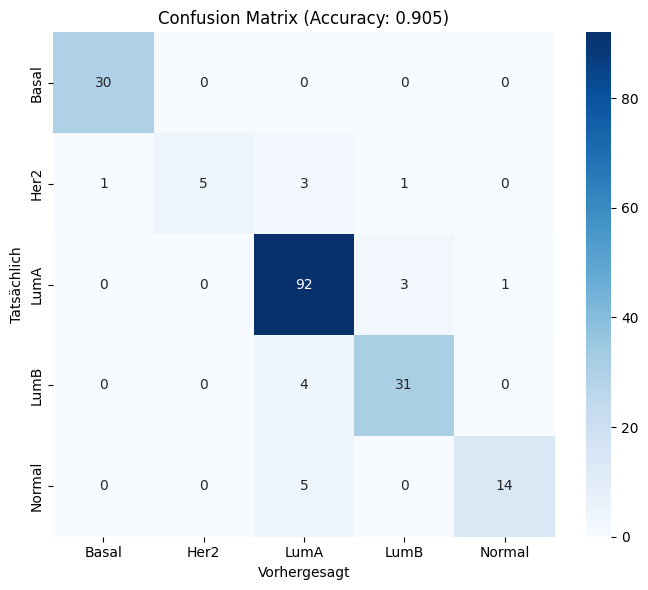

In [21]:
# --- Confusion Matrix ---
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Vorhergesagt")
ax.set_ylabel("Tatsächlich")
ax.set_title(f"Confusion Matrix (Accuracy: {acc:.3f})")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


Top 10 wichtigste Gene:
FAM171A1     0.005126
C6orf97      0.004849
CT62         0.004491
STAC         0.004417
UBE2T        0.004415
CNN1         0.004339
LOC728264    0.003991
MLPH         0.003902
SPRY2        0.003840
FOXC1        0.003743
dtype: float64


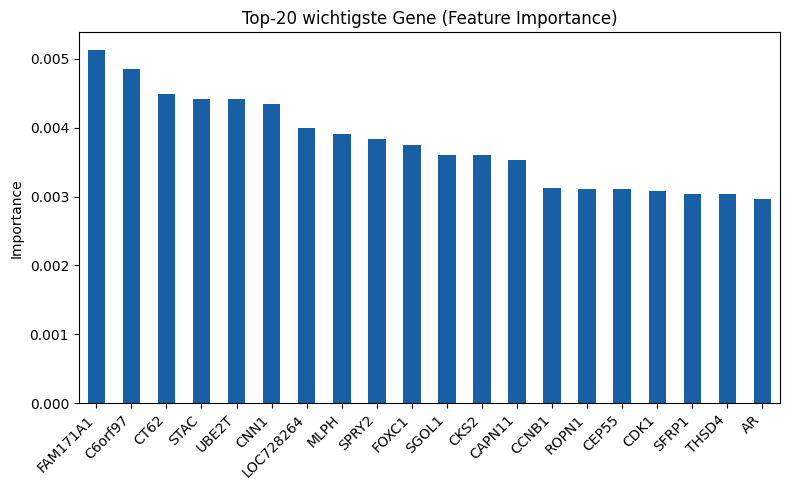

In [22]:
# --- Top-20 Feature Importance ---
importances = rf.feature_importances_
X_train_df = pd.DataFrame(X_train)  # wenn nötig
feat_imp = pd.Series(importances,
    index=X_train.columns if hasattr(X_train, "columns") else range(len(importances))
).sort_values(ascending=False)

print("\nTop 10 wichtigste Gene:")
print(feat_imp.head(10))

fig2, ax2 = plt.subplots(figsize=(8, 5))
feat_imp.head(20).plot(kind="bar", ax=ax2, color="#185FA5", edgecolor="none")
ax2.set_title("Top-20 wichtigste Gene (Feature Importance)")
ax2.set_ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## Hyperparameter-Tuning

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import joblib, numpy as np

X_train, X_test, y_train, y_test = joblib.load("C:\\Users\\niels\\OneDrive\\ETH\\FS26\\Foundations of Data Science\\Group Project\\Random_Forest_v1\\preprocessed.pkl")

In [24]:
param_dist = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [None, 10, 20, 30],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2", 0.1, 0.2],
}


In [25]:
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [26]:
search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=30,              # 30 zufällige Kombinationen testen
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

search.fit(X_train, y_train)

print(f"Beste Parameter: {search.best_params_}")
print(f"Beste CV-Accuracy: {search.best_score_:.4f}")

# Bestes Modell speichern
joblib.dump(search.best_estimator_, "rf_tuned.pkl")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Beste Parameter: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.1, 'max_depth': None}
Beste CV-Accuracy: 0.9039


['rf_tuned.pkl']

## Dimensionsreduktion

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder


In [30]:
X_train, X_test, y_train, y_test = joblib.load("C:\\Users\\niels\\OneDrive\\ETH\\FS26\\Foundations of Data Science\\Group Project\\Random_Forest_v1\\preprocessed.pkl")

# Alle Daten zusammenführen für PCA
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

# PCA auf 50 Komponenten (schneller als direkt 2D)
pca = PCA(n_components=50, random_state=42)
X_pca50 = pca.fit_transform(X_all)
print(f"Varianzanteil (50 Komp.): {pca.explained_variance_ratio_.sum():.3f}")

# Nur erste 2 für Plot
X_2d = X_pca50[:, :2]

Varianzanteil (50 Komp.): 0.619


## Visualisierung

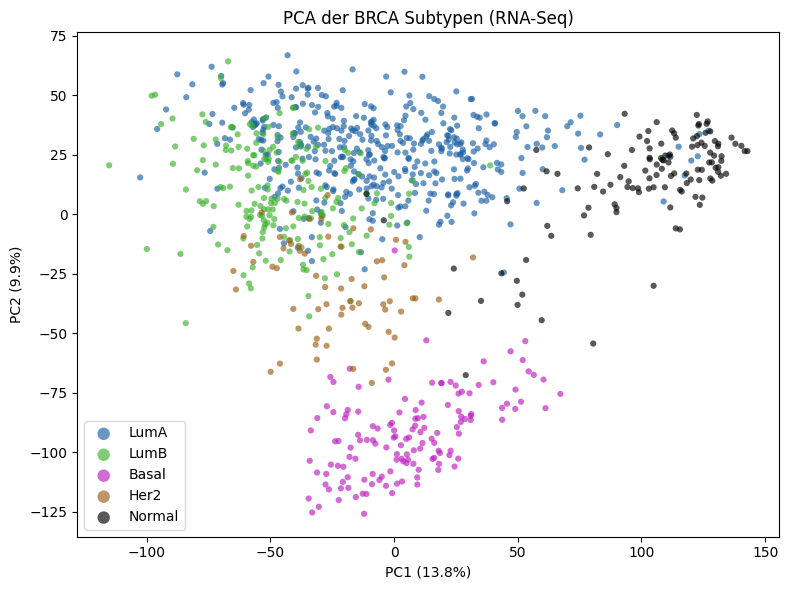

In [33]:
# Plot
colors = {
    "LumA":   "#185FA5",
    "LumB":   "#3AB12A",
    "Basal":  "#BD1BBD",
    "Her2":   "#9E5D12",
    "Normal": "#000000"
}
fig, ax = plt.subplots(figsize=(8, 6))
for subtype, color in colors.items():
    mask = y_all == subtype
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=subtype, color=color,
               alpha=0.65, s=20, edgecolors="none")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA der BRCA Subtypen (RNA-Seq)")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("pca_subtypes.png", dpi=150)
plt.show()
